# Traitement de données vectorielles

`VectorTools` enveloppe un `GeoDataFrame` et expose des méthodes
**chaînables** organisées en trois temps :

1. **prétraitement** : validité, CRS, nettoyage, filtrage, découpage, topologie
2. **analyse** : géométrie, mesures, superposition, jointures, proximité, densité
3. **post-traitement** : reclassement, généralisation, export

Chaque méthode renvoie un nouvel objet `VectorTools` ; `.gdf` récupère le
`GeoDataFrame`. Le module fournit aussi des fonctions simples :
`centroids`, `join`, `fusion`, `add_column`, `get_geometry_types`.

In [ ]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # cartograpy est à la racine du dépôt
logging.basicConfig(level=logging.INFO, format="%(message)s")

import numpy as np
import geopandas as gpd
from shapely.geometry import Point

import cartograpy as cp
from cartograpy import VectorTools, centroids
from cartograpy.processing import get_geometry_types
from cartograpy.data import Bound

UTM = "EPSG:32630"  # UTM 30N : mètres, pour mesures et tampons

bound = Bound()
regions = bound.get_admin("CIV", adm=1).set_crs("EPSG:4326")
depts = bound.get_admin("CIV", adm=2).set_crs("EPSG:4326")
civ = bound.get_country("CIV").set_crs("EPSG:4326")
print(len(regions), "régions,", len(depts), "départements")

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


14 régions, 33 départements


## 1. Prétraitement

Corriger les géométries invalides, retirer les vides, passer en projection
métrique : tout s'enchaîne en une expression.

In [2]:
print("géométries valides :", VectorTools(regions).validity().mean() * 100, "%")

regions_m = (
    VectorTools(regions)
    .fix_invalid()
    .remove_empty()
    .reproject_layer(UTM)
    .gdf
)
depts_m = VectorTools(depts).fix_invalid().remove_empty().reproject_layer(UTM).gdf

print("CRS de travail :", regions_m.crs)
get_geometry_types(regions_m)  # affiche la répartition des types

géométries valides : 100.0 %
CRS de travail : EPSG:32630
Polygon: 14 (100.0%)


## 2. Mesures géométriques

`area`, `perimeter`, `compactness` (4πA/P²), `shape_index`… ajoutent une
colonne. En projection métrique, les surfaces sont en m².

In [3]:
mesure = (
    VectorTools(regions_m)
    .area("aire_m2")
    .perimeter("perimetre_m")
    .compactness("compacite")
    .gdf
)
mesure["aire_km2"] = mesure["aire_m2"] / 1e6

# on rattache les colonnes à la version EPSG:4326 pour la carte
regions_plot = regions.copy()
for col in ("aire_km2", "compacite"):
    regions_plot[col] = mesure[col].values

regions_plot[["shapeName", "aire_km2", "compacite"]].sort_values("aire_km2", ascending=False).head()

,shapeName,aire_km2,compacite
8,Savanes,40145.665186,0.166860
11,Zanzan,38157.188325,0.336271
10,Woroba,31100.590331,0.191719
6,Montagnes,30824.763583,0.289505
0,Bas-Sassandra,28330.393860,0.328770


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


   Étendue: [-11.00, -0.08, 3.91, 11.19]


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


   Étendue: [-11.00, -0.08, 3.91, 11.19]


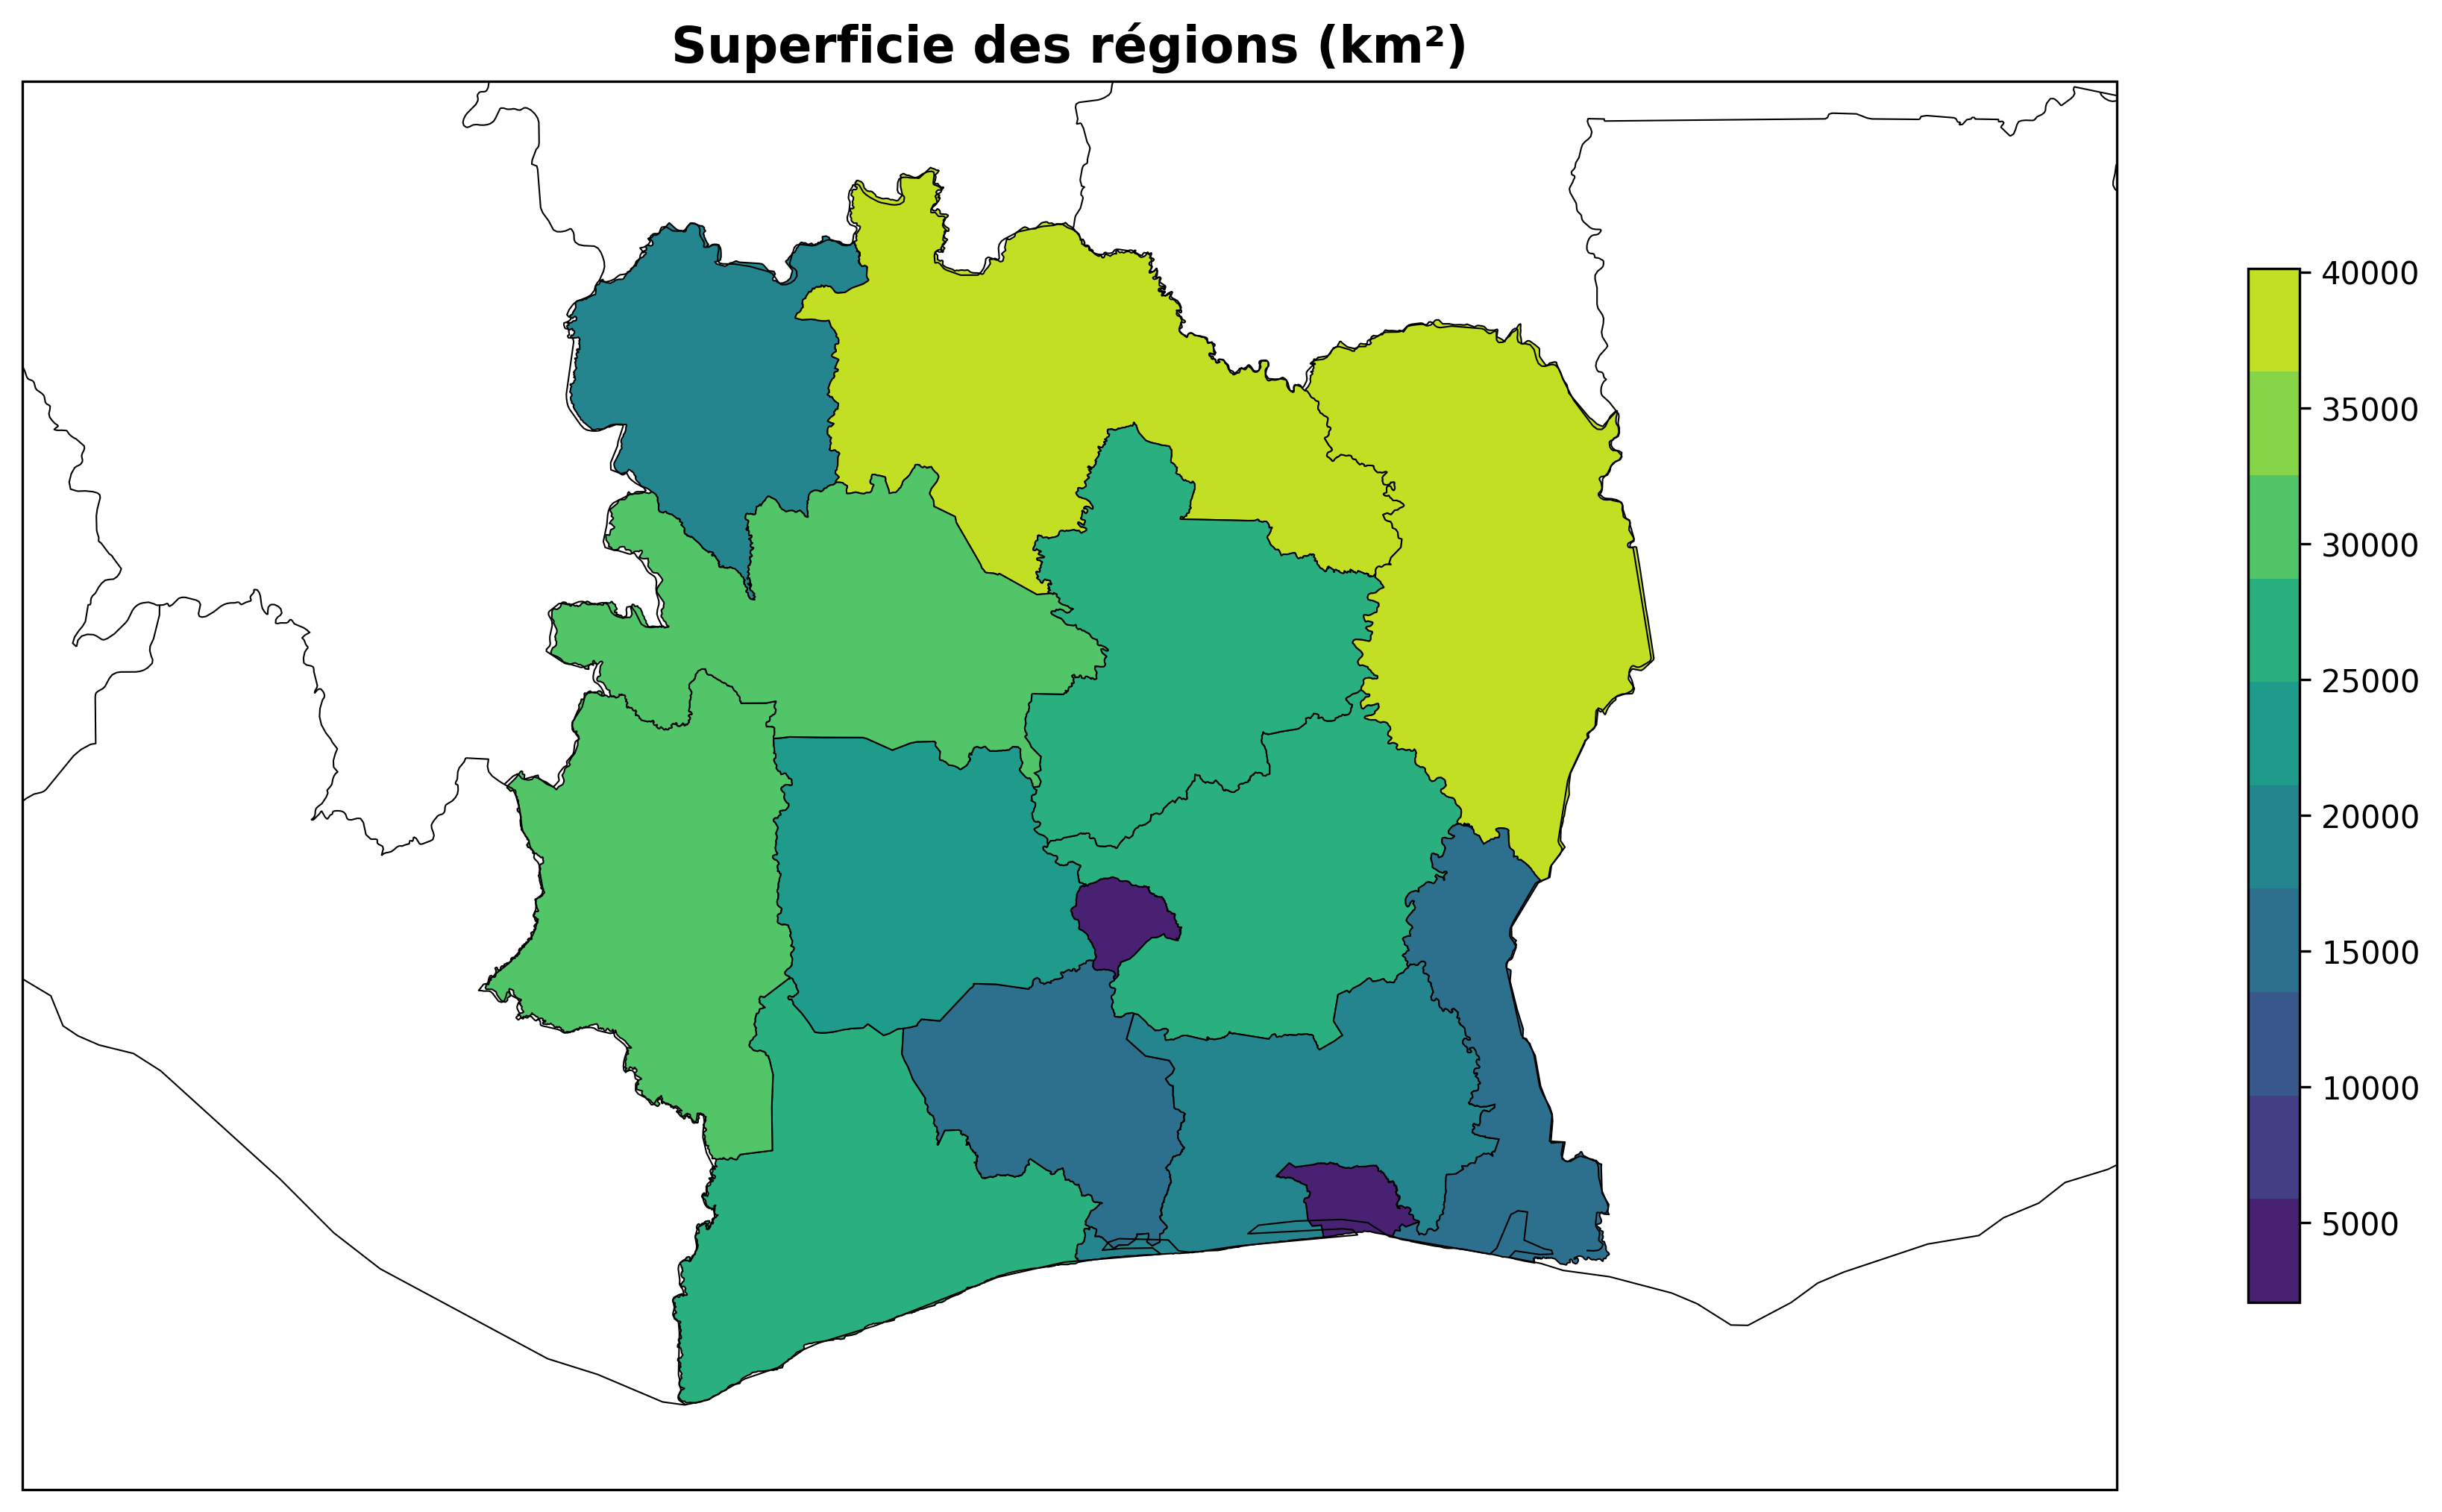

In [4]:
m = cp.Map(title="Superficie des régions (km²)")
m.add_polygons_choropleth(regions_plot, column_to_plot="aire_km2", cmap="viridis", show_labels=False)
m.show()

## 3. Centroïdes et zones tampons

`centroids()` renvoie les centres ; `buffer(distance)` crée une zone tampon
(en mètres ici).

C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\pandas\core\generic.py:6335: DeprecationWarning: Overriding the CRS of a GeoDataFrame that already has CRS. This unsafe behavior will be deprecated in future versions. Use GeoDataFrame.set_crs method instead
  return object.__setattr__(self, name, value)


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


   Étendue: [-11.00, -0.08, 3.91, 11.19]


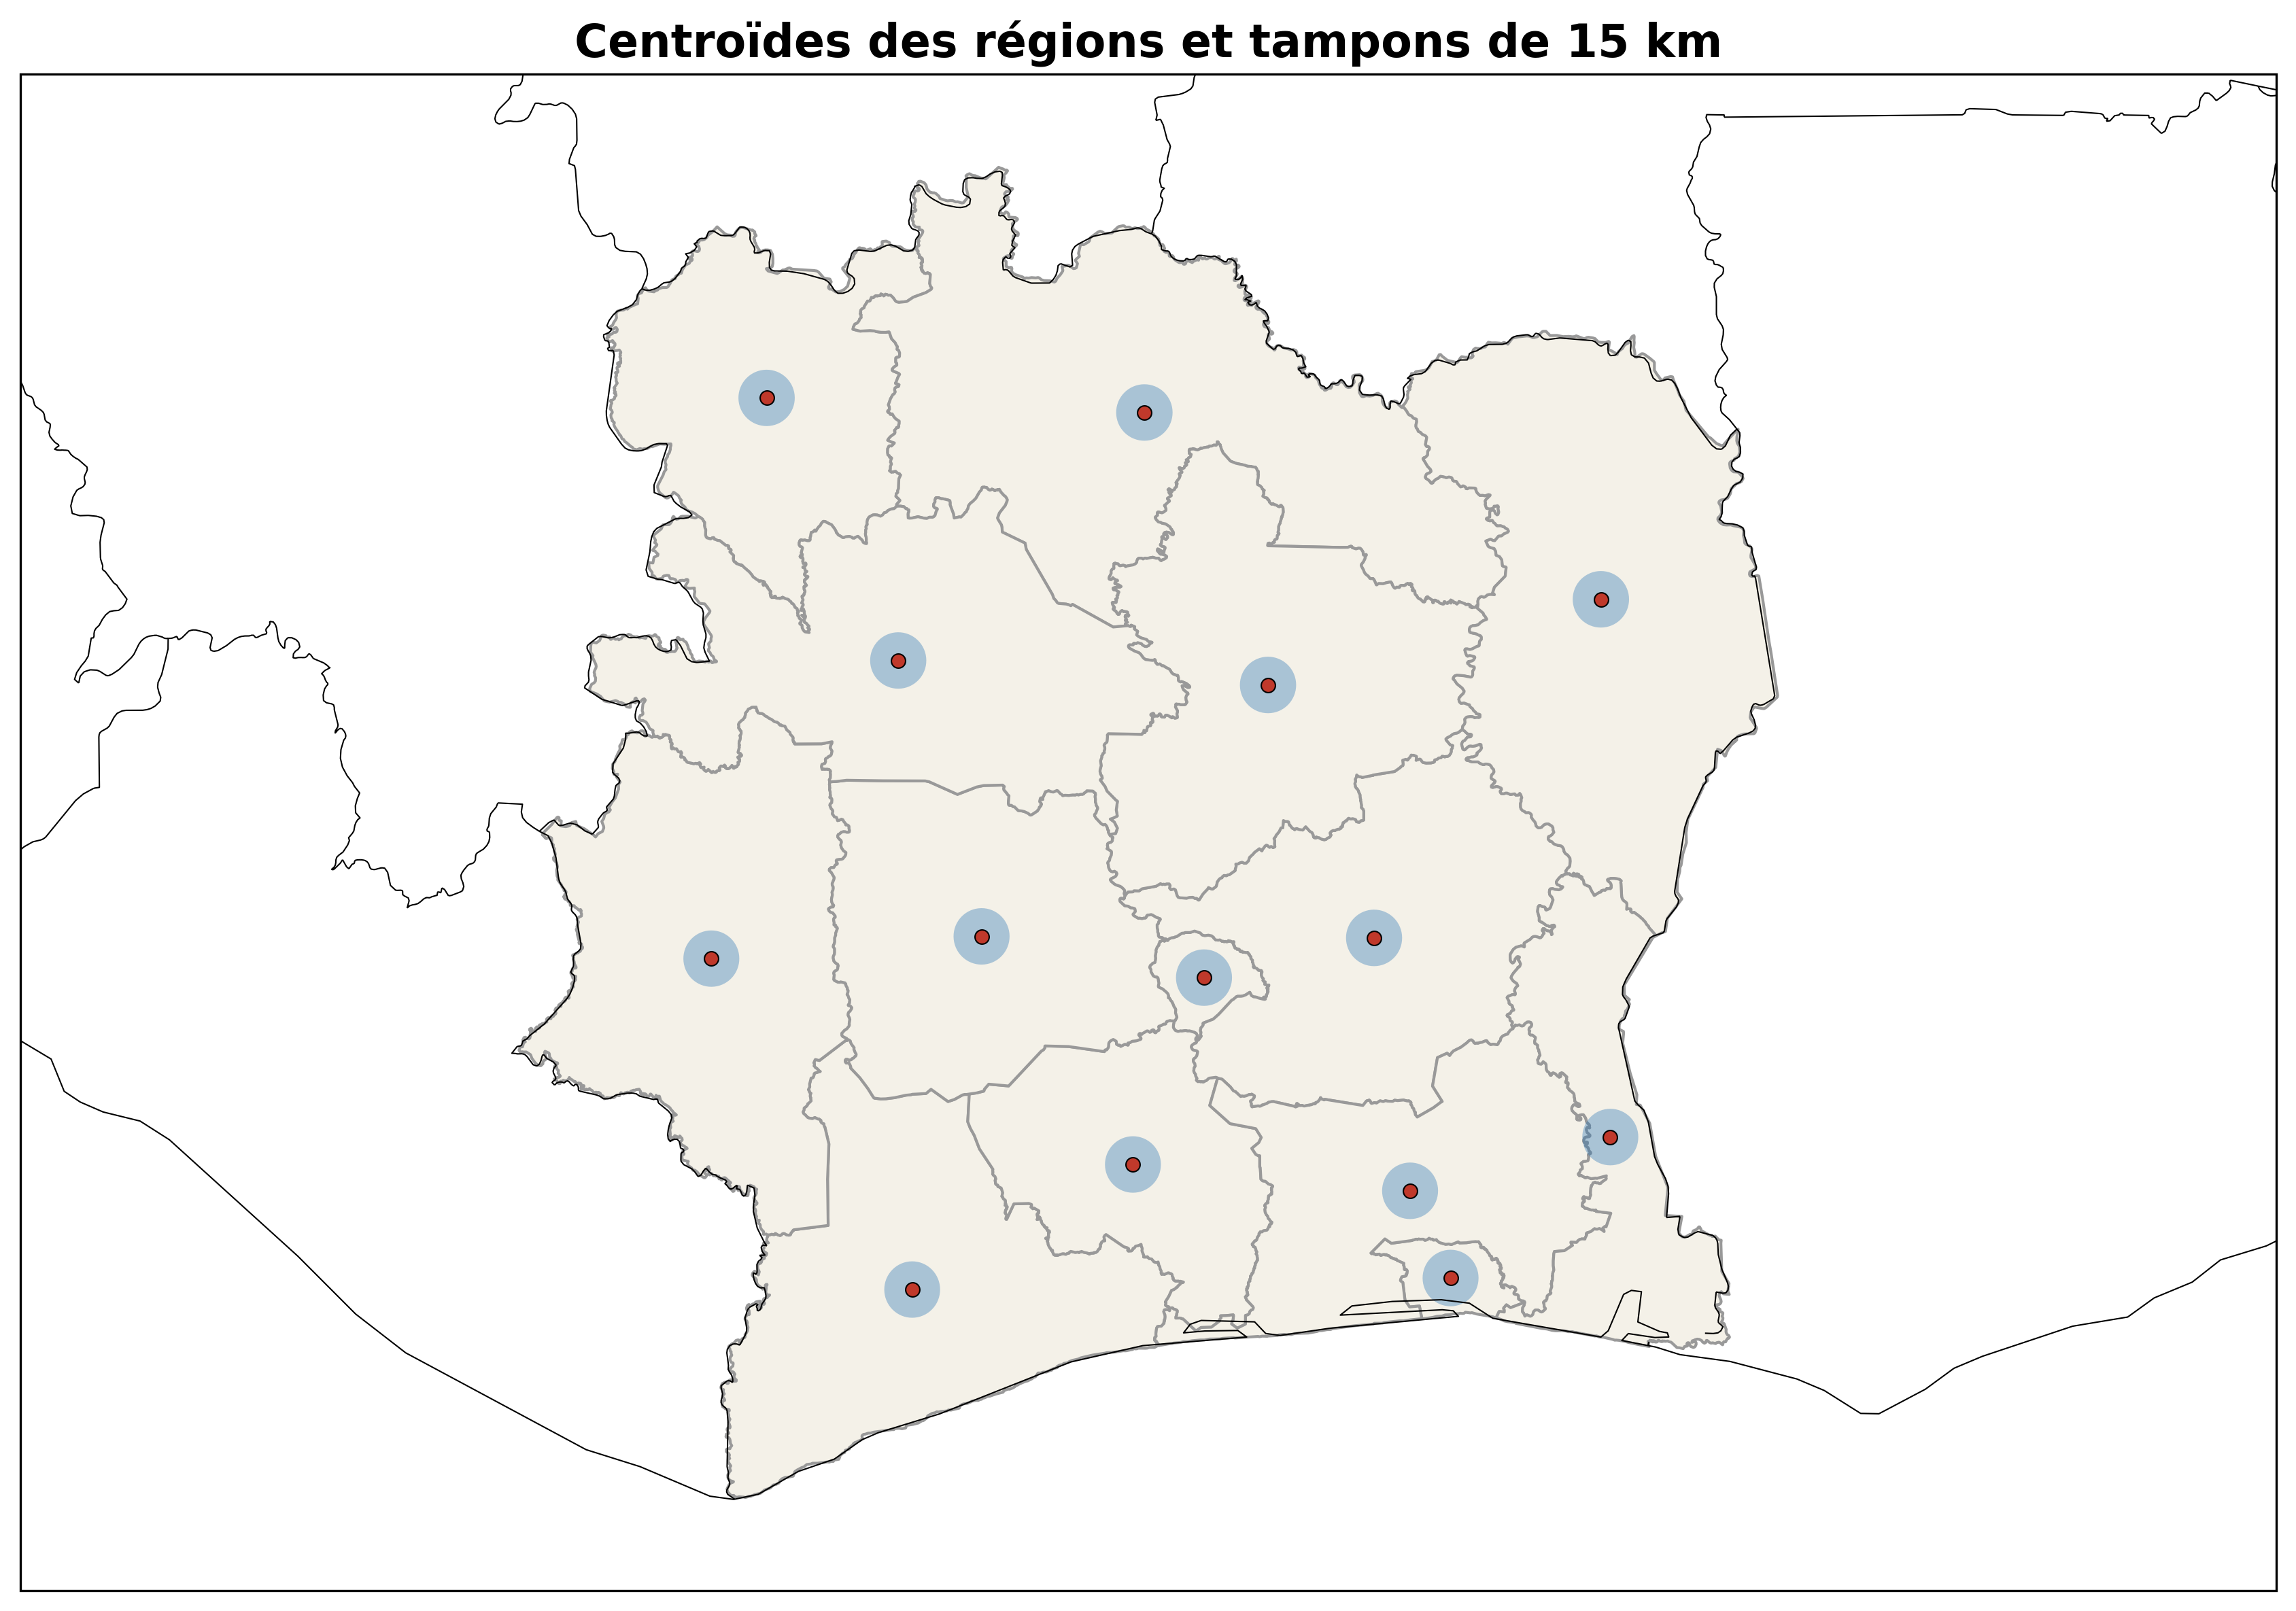

In [5]:
centres_m = centroids(regions_m)
tampons_m = VectorTools(centres_m).buffer(15000).gdf   # 15 km

m = cp.Map(title="Centroïdes des régions et tampons de 15 km")
m.add_polygons(regions, facecolor="#f4f1e8", edge_color="#999999", alpha=1)
m.add_polygons(tampons_m.to_crs("EPSG:4326"), facecolor="#1f6fb2", edge_color="none", alpha=0.35)
m.add_points(centres_m.to_crs("EPSG:4326"), color="#c0392b", size=25)
m.show()

## 4. Superposition : différence

`difference` (comme `intersection`, `union`, `symmetric_difference`)
s'appuie sur `geopandas.overlay`. Ici : les départements *privés* d'un
rayon de 30 km autour de Yamoussoukro.

📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


   Étendue: [-11.00, -0.08, 3.91, 11.19]


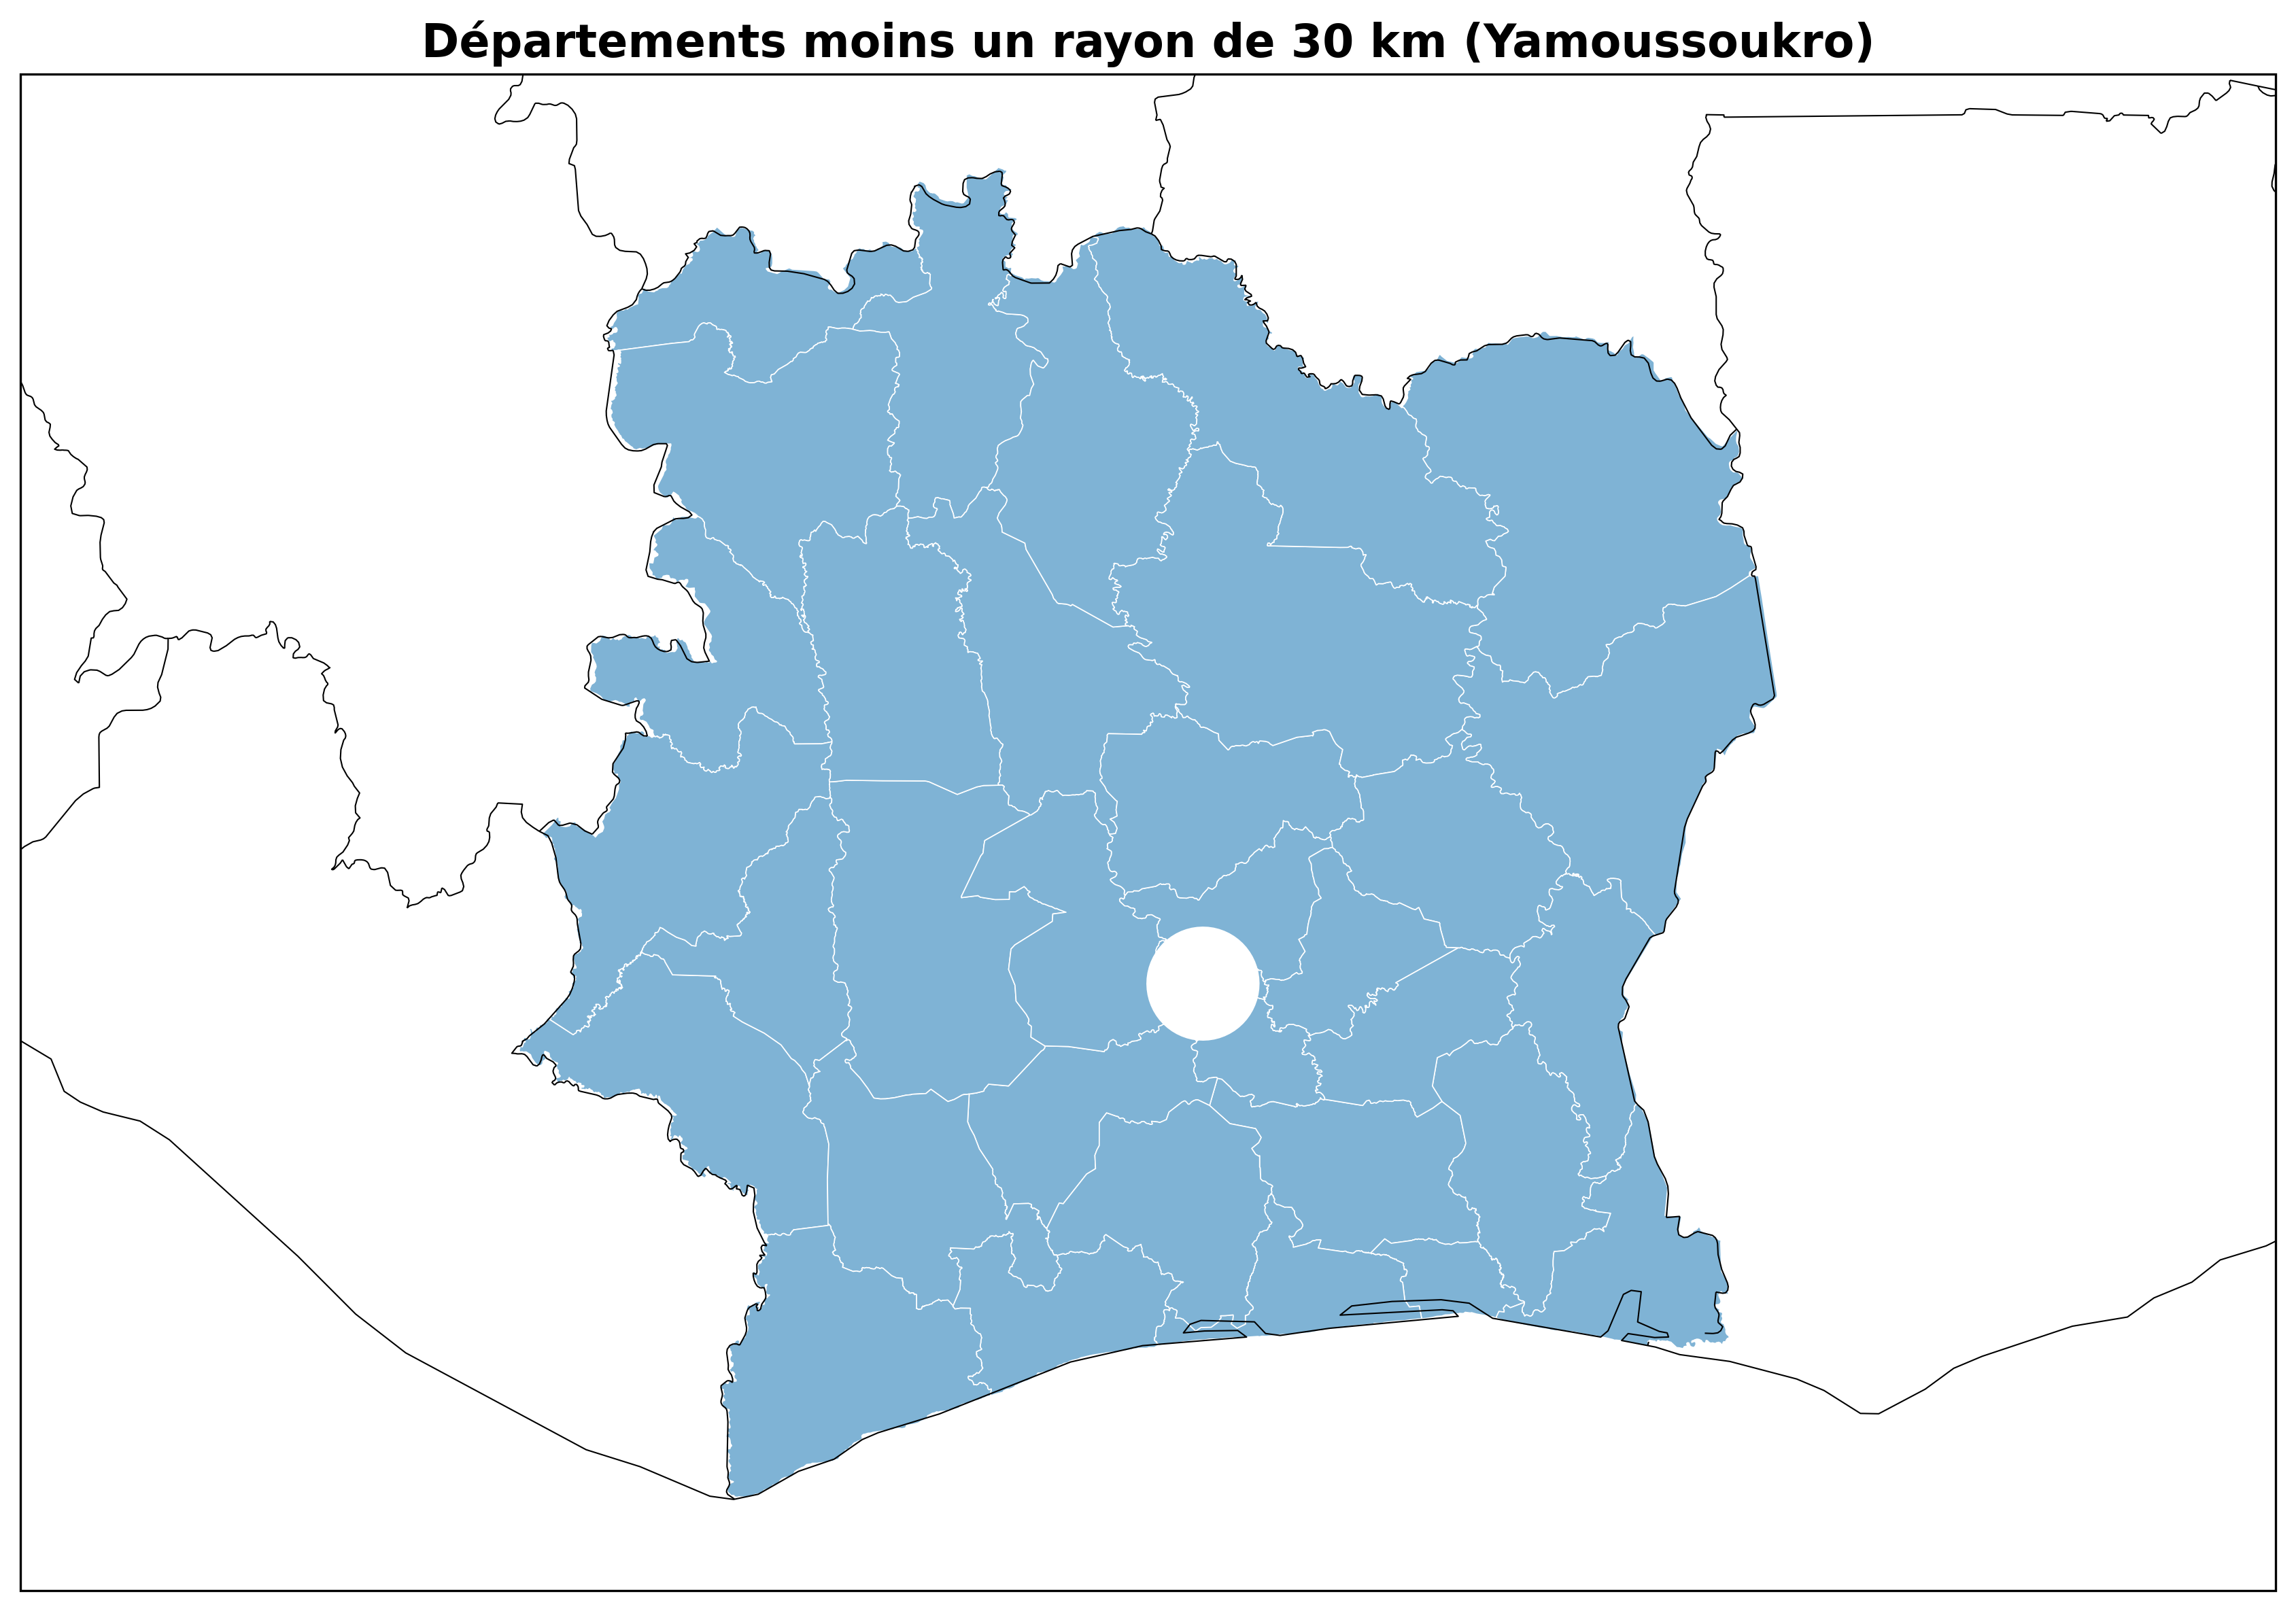

In [6]:
yamo_m = gpd.GeoSeries([Point(-5.273, 6.827)], crs="EPSG:4326").to_crs(UTM).iloc[0]
zone = gpd.GeoDataFrame(geometry=[yamo_m.buffer(30000)], crs=UTM)

troues = VectorTools(depts_m).difference(zone).gdf

m = cp.Map(title="Départements moins un rayon de 30 km (Yamoussoukro)")
m.add_polygons(troues.to_crs("EPSG:4326"), facecolor="#7fb3d5", edge_color="white", linewidth=0.4, alpha=1)
m.show()

## 5. Jointure spatiale et comptage

On sème 800 points aléatoires, on garde ceux qui tombent en Côte d'Ivoire,
puis `point_in_polygon_join` rattache chaque point à son département.

530 points retenus


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


...

📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


   Étendue: [-11.00, -0.08, 3.91, 11.19]


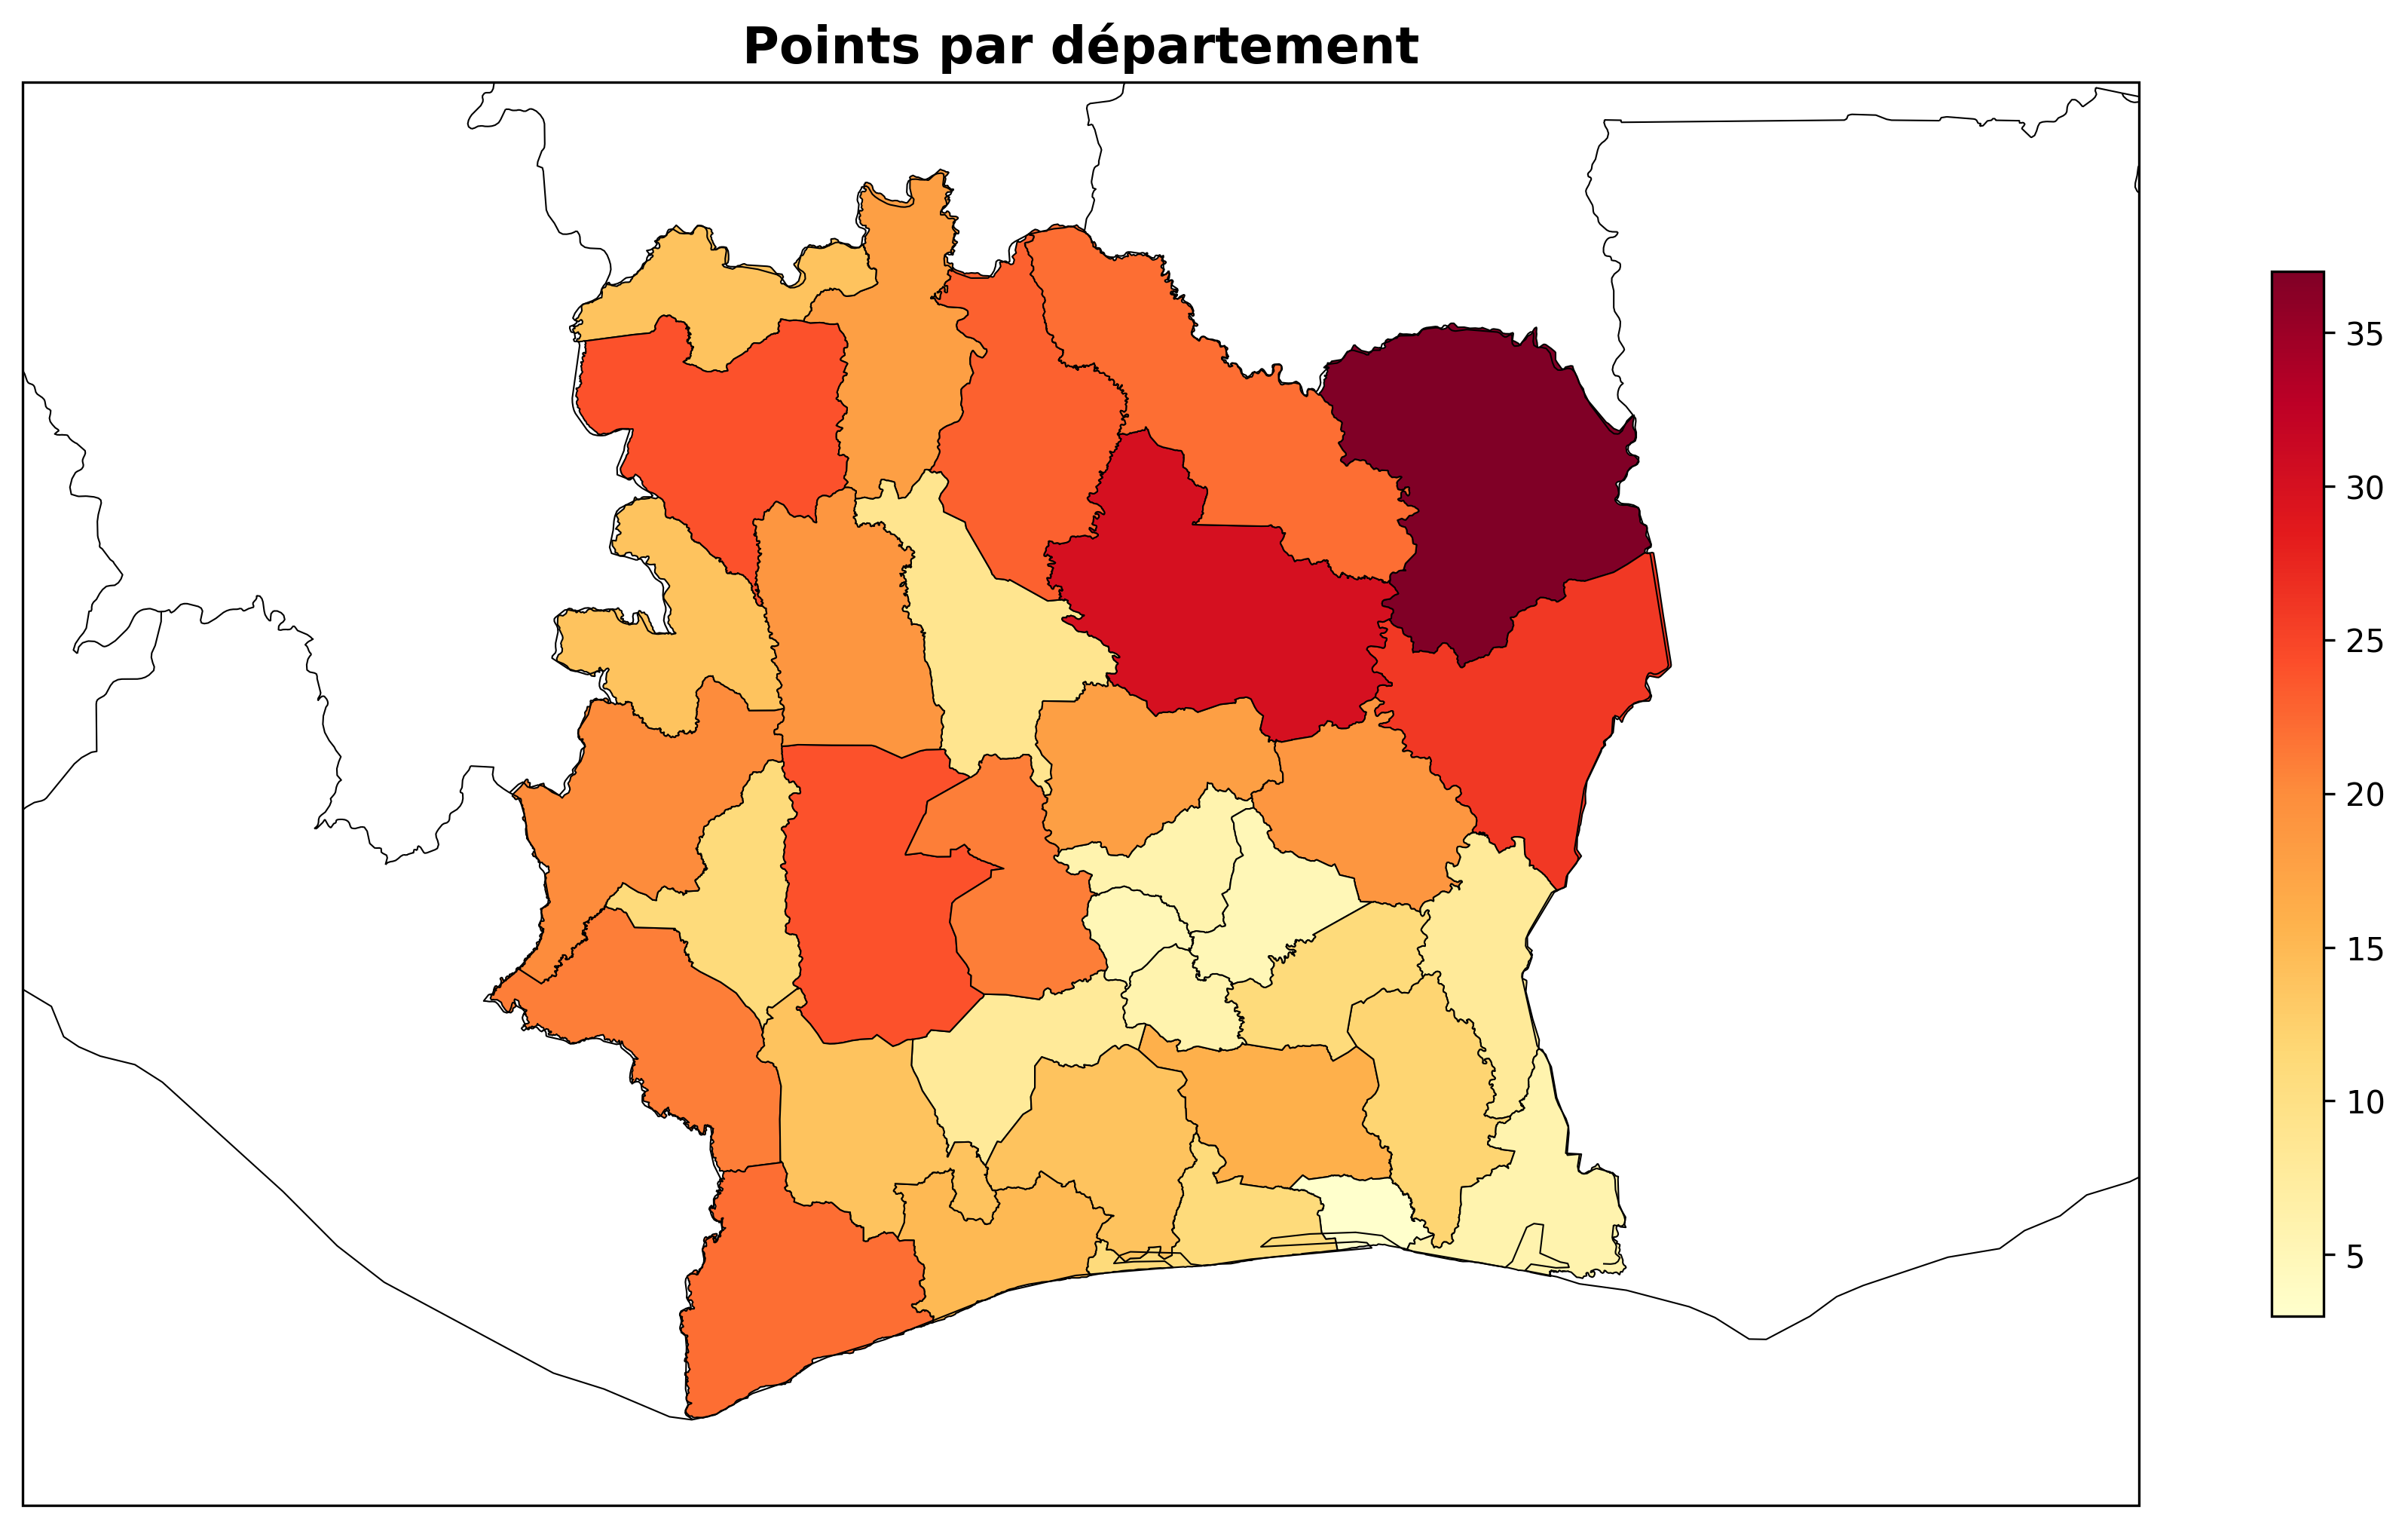

In [7]:
rng = np.random.default_rng(42)
minx, miny, maxx, maxy = civ.total_bounds
semis = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(rng.uniform(minx, maxx, 800), rng.uniform(miny, maxy, 800)),
    crs="EPSG:4326",
)
pts = semis[semis.within(civ.union_all())].reset_index(drop=True).to_crs(UTM)
print(len(pts), "points retenus")

rattaches = VectorTools(pts).point_in_polygon_join(depts_m).gdf
par_dept = rattaches.groupby("shapeName").size().rename("n_points").reset_index()

depts_plot = depts.merge(par_dept, on="shapeName", how="left")
depts_plot["n_points"] = depts_plot["n_points"].fillna(0)

m = cp.Map(title="Points par département")
m.add_polygons_choropleth(depts_plot, column_to_plot="n_points", cmap="YlOrRd", show_labels=False)
m.show()

## 6. Proximité et densité

`point_density` compte les voisins dans un rayon ; `distance_to_nearest`
mesure la distance à la couche la plus proche (ici les chefs-lieux =
centroïdes de régions).

📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.96


   Étendue: [-11.02, -0.11, 3.90, 11.17]


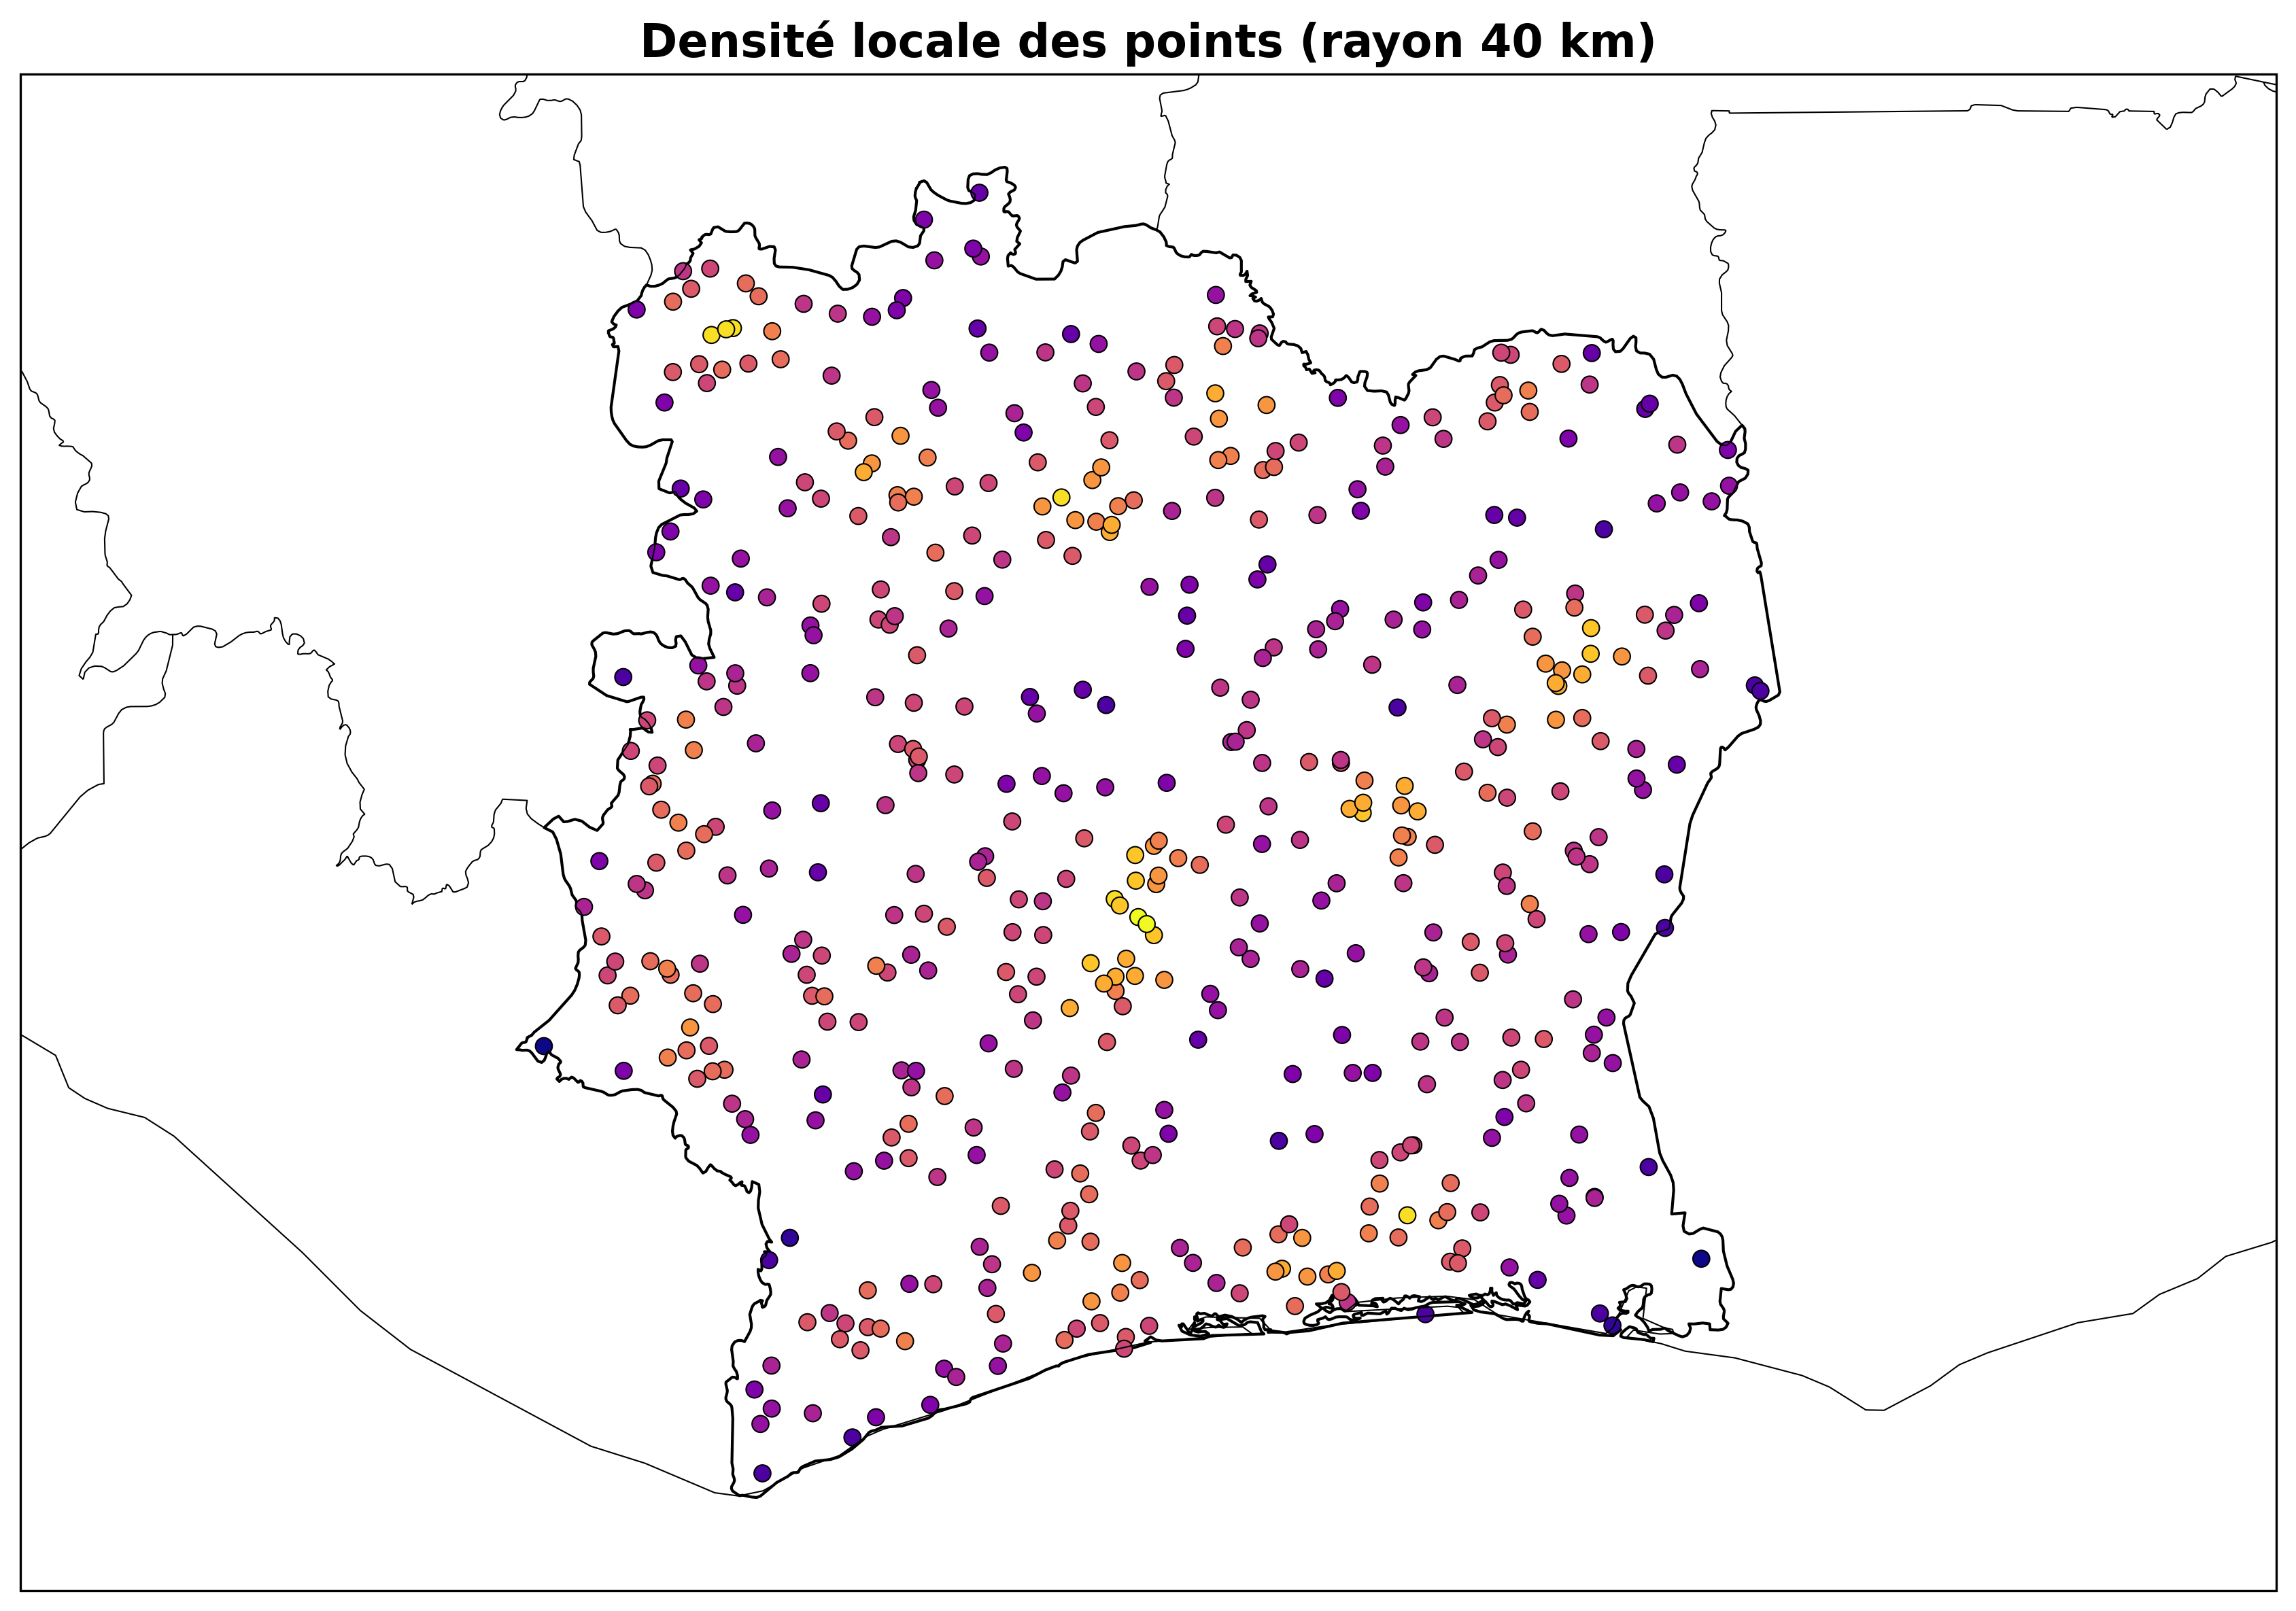

In [8]:
analyse = (
    VectorTools(pts)
    .point_density(radius=40000, column_name="densite")     # points / km² dans 40 km
    .distance_to_nearest(centres_m, column_name="dist_chef_lieu")
    .gdf
)
analyse["dist_km"] = analyse["dist_chef_lieu"] / 1000

m = cp.Map(title="Densité locale des points (rayon 40 km)")
m.add_polygons(civ, facecolor="none", edge_color="black", linewidth=1, alpha=1)
m.add_points(analyse.to_crs("EPSG:4326"), column="densite", cmap="plasma", size=35)
m.show()

## 7. Post-traitement : classement, simplification, export

In [9]:
Path("_vector_cache").mkdir(exist_ok=True)

final = (
    VectorTools(regions_plot)
    .rank_features("aire_km2", ascending=False, rank_column="rang_superficie")
    .simplify_geometry(0.01, preserve_topology=True)
)
final.to_geojson("_vector_cache/regions_civ_traitees.geojson")

final.gdf[["shapeName", "aire_km2", "rang_superficie"]].sort_values("rang_superficie").head()

Created 14 records


,shapeName,aire_km2,rang_superficie
8,Savanes,40145.665186,1
11,Zanzan,38157.188325,2
10,Woroba,31100.590331,3
6,Montagnes,30824.763583,4
0,Bas-Sassandra,28330.393860,5
